# Imports

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [23]:
from preprocessing_module import Preprocess
from data_visualiser_module import DataVisualiser

# Load dataset

In [24]:


# base path
base_path = "../data/raw/"
years = [2021, 2022, 2023]  

# Read
data = pd.concat([pd.read_csv(f"{base_path}CH_{year}_hourly.csv") for year in years], ignore_index=True)



Drop unnecessary Columns

In [25]:
columns_to_drop=['Country','Zone Name','Zone Id','Data Source','Data Estimated','Data Estimation Method']
df=Preprocess(data)
df.drop(column_names=columns_to_drop)

['Country', 'Zone Name', 'Zone Id', 'Data Source', 'Data Estimated', 'Data Estimation Method'] have been dropped


# Dataset Info

In [26]:
df.data.head()

,Datetime (UTC),Carbon Intensity gCO₂eq/kWh (direct),Carbon Intensity gCO₂eq/kWh (LCA),Low Carbon Percentage,Renewable Percentage
0,01/01/2021 00:00,147.82,187.06,80.25,35.14
1,01/01/2021 01:00,159.56,199.85,78.84,33.17
2,01/01/2021 02:00,140.89,179.60,80.34,33.88
3,01/01/2021 03:00,122.40,159.06,81.49,30.38
4,01/01/2021 04:00,142.60,180.92,80.02,30.54


Dataframe overview and missing values

In [27]:
df.data_overview()


Basic data overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Datetime (UTC)                        26280 non-null  object 
 1   Carbon Intensity gCO₂eq/kWh (direct)  26280 non-null  float64
 2   Carbon Intensity gCO₂eq/kWh (LCA)     26280 non-null  float64
 3   Low Carbon Percentage                 26280 non-null  float64
 4   Renewable Percentage                  26280 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.0+ MB


Summary Statistics
       Carbon Intensity gCO₂eq/kWh (direct)  \
count                          26280.000000   
mean                              83.048511   
std                               55.106640   
min                                3.490000   
25%                               40.237500   
50%                               68.060000   
7

In [28]:
#datetime
df.convert_to_datetime('Datetime (UTC)')

check outliers

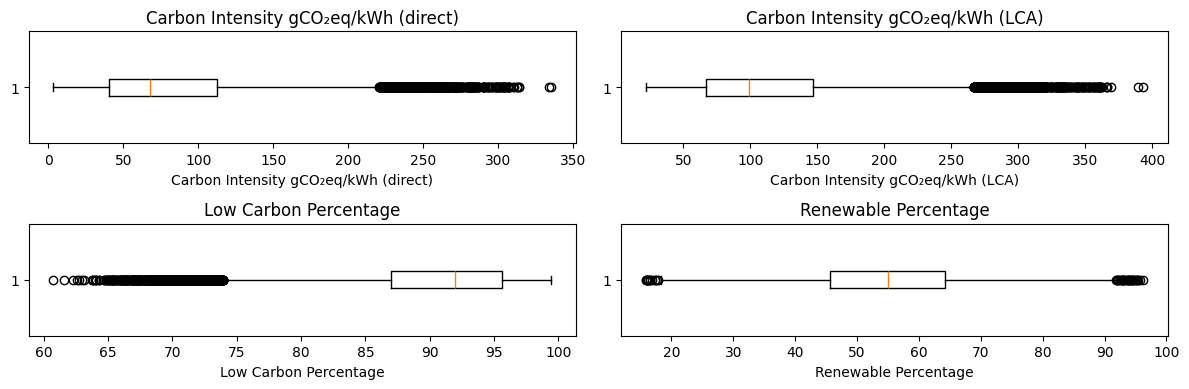

In [29]:
df.box_plot_outlier(rows=2,columns=2)

In [30]:
# check missing values
df.check_missing_values()

Carbon Intensity gCO₂eq/kWh (direct)    0
Carbon Intensity gCO₂eq/kWh (LCA)       0
Low Carbon Percentage                   0
Renewable Percentage                    0
dtype: int64

# Plot

In [31]:
df_visualize=DataVisualiser(df.data)

In [32]:
df_visualize.data.head()

,Carbon Intensity gCO₂eq/kWh (direct),Carbon Intensity gCO₂eq/kWh (LCA),Low Carbon Percentage,Renewable Percentage
Datetime (UTC),,,,
2021-01-01 00:00:00,147.82,187.06,80.25,35.14
2021-01-01 01:00:00,159.56,199.85,78.84,33.17
2021-01-01 02:00:00,140.89,179.60,80.34,33.88
2021-01-01 03:00:00,122.40,159.06,81.49,30.38
2021-01-01 04:00:00,142.60,180.92,80.02,30.54


# Data renewable and cabon intensitygCO₂eq/kWh (direct) and LCA dual y axis . 


Inverse relationship between carbon intensity and renewable energy. We see the reason for the outlier. When renewable energy is high Carbon Intensity is low. This means when there is higher share of renewable energy there is low emission per KHH of electriccity generated.

- During summer we see higher renewable percentages and during winter it is lower.
- or carbon intensity we see higher during winter and lower during summer.

We also see the low carbon percentage is higher than renewable percentage since it includes nuclear and other non renewable carbon sources. We see a high Low carbon percentage with a low carbon intensity. When there is  low renewable percentage and high Low carbon percentage means nuclear energy is being used.

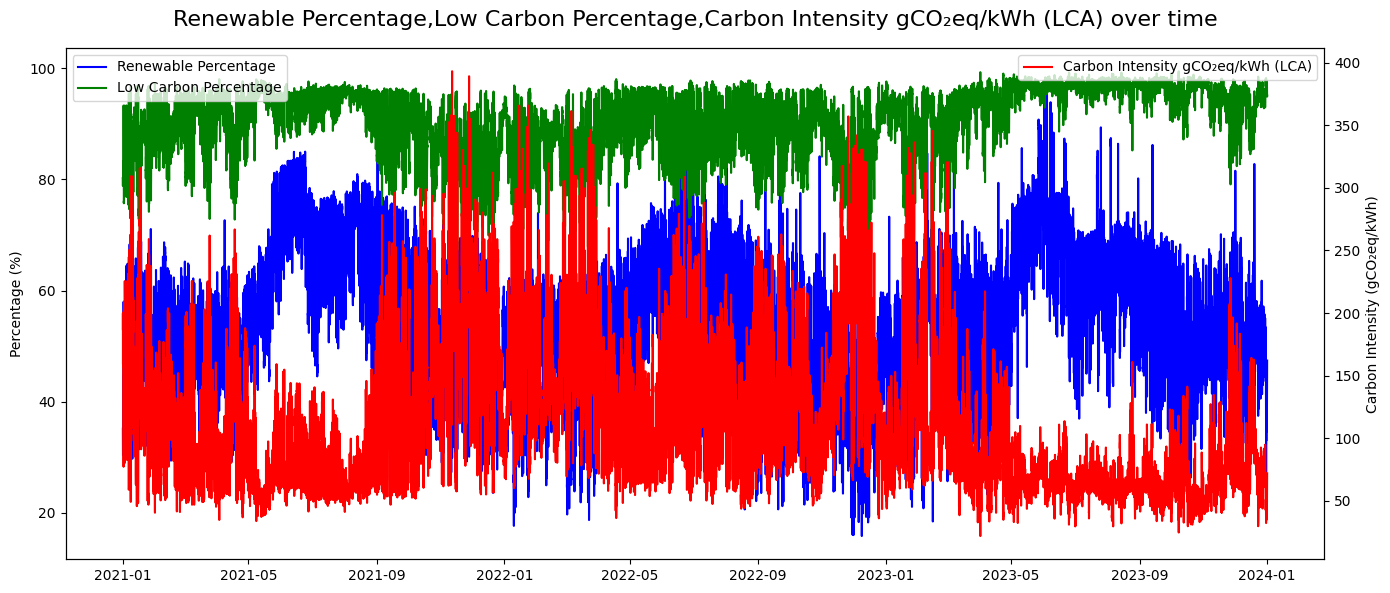

In [33]:
df_visualize.dual_axis_plot( primary_columns=['Renewable Percentage','Low Carbon Percentage'],
    secondary_columns=['Carbon Intensity gCO₂eq/kWh (LCA)'],
    ylabel1='Percentage (%)',
    ylabel2='Carbon Intensity (gCO₂eq/kWh)')

# Outliers

### Renewable percentage

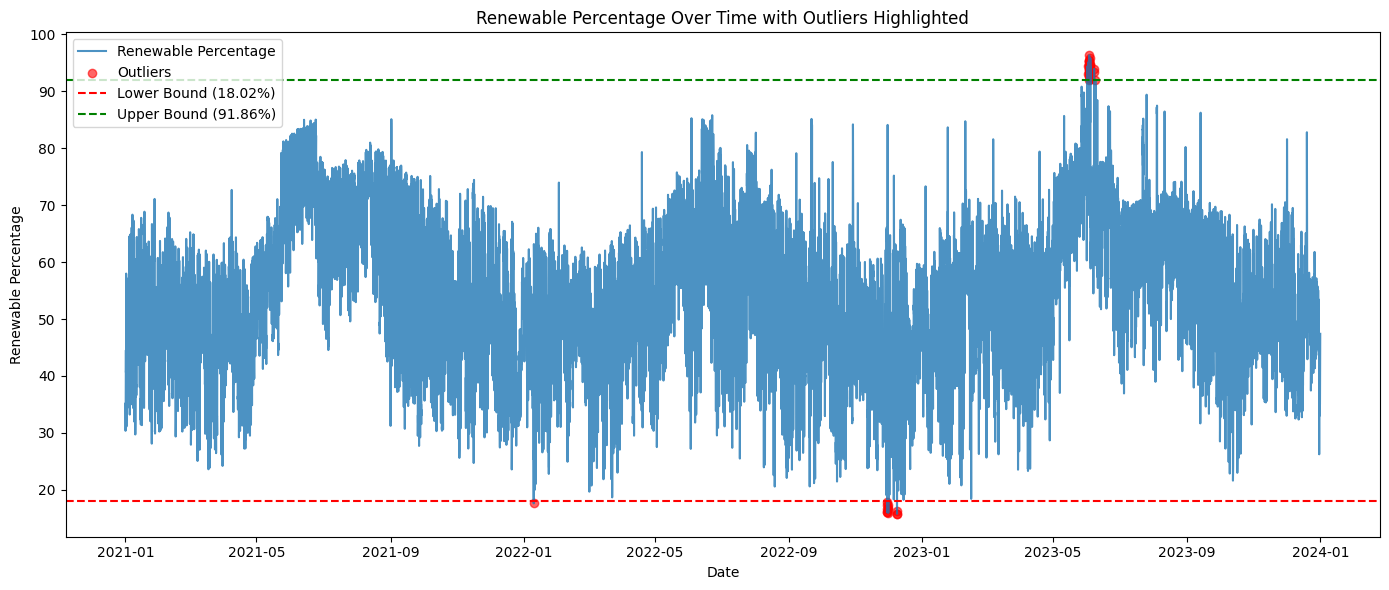

In [34]:
# plot oulier with the upper bound and lower band
df_visualize.outlier_plot(column_name='Renewable Percentage',title='Renewable Percentage Over Time with Outliers Highlighted')


### Low Carbon Percentage

We see outliers on lower bound. This might be us more use of renewable energy,higher fossil fuel reliance.

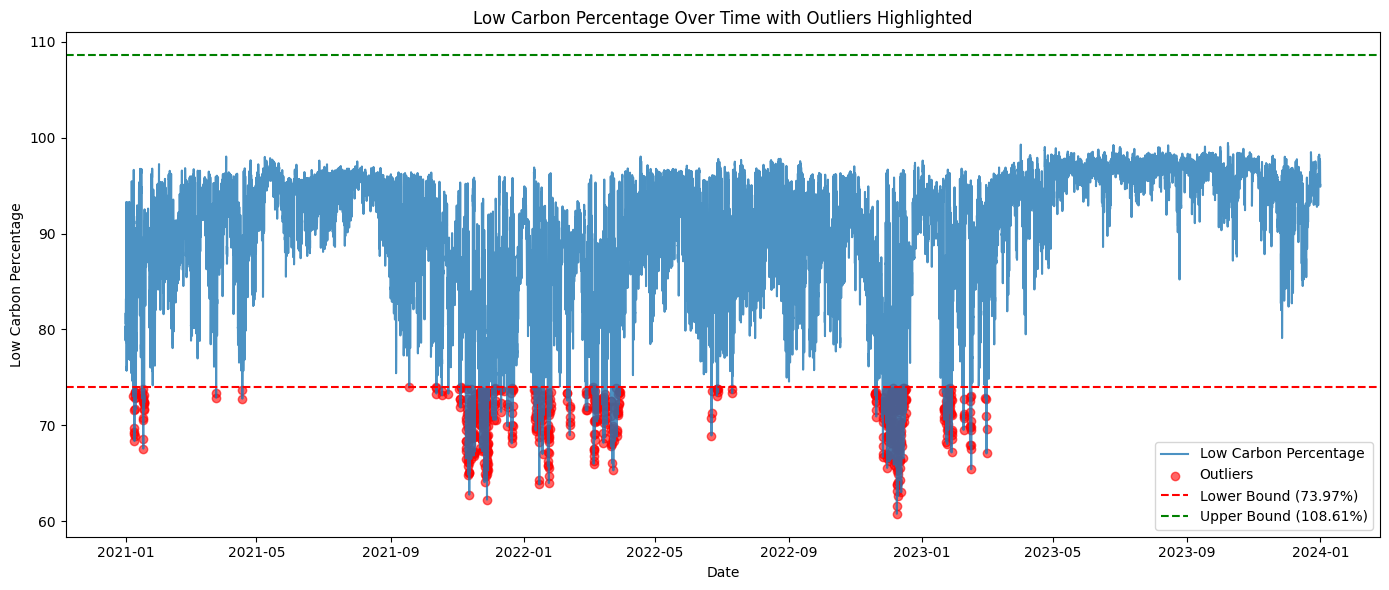

In [35]:
# plot oulier with the upper bound and lower band
df_visualize.outlier_plot(column_name='Low Carbon Percentage',title='Low Carbon Percentage Over Time with Outliers Highlighted')


# Weekly

We observe that the carbon intensity for, both direct and Lca, is the highest on saturdays and lower mondays.

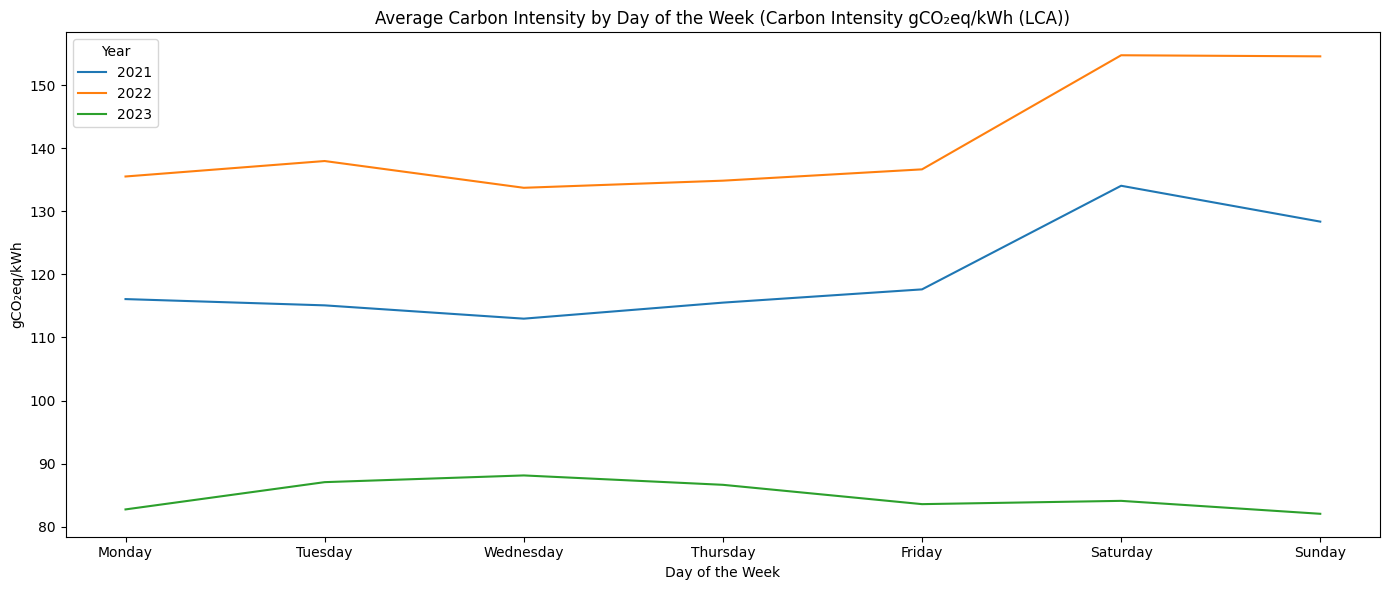

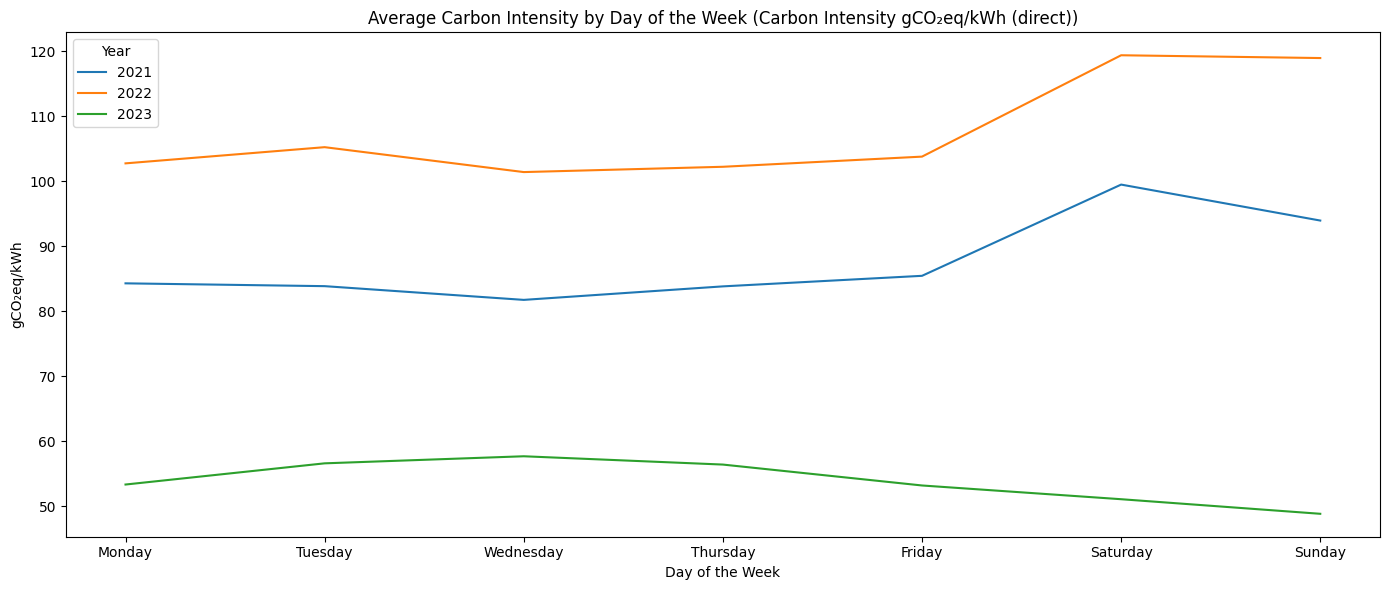

In [36]:
df_visualize.plot_weekday_trends(
    columns=['Carbon Intensity gCO₂eq/kWh (LCA)','Carbon Intensity gCO₂eq/kWh (direct)'],
    title="Average Carbon Intensity by Day of the Week",
    ylabel="gCO₂eq/kWh"
)


Renewable percentage peaks during the week ends. But during the week days the renwable percentage and Low Carbon percentages are lower might attribute industrial demands.
The year 2023 there is higher use of renewable energy.

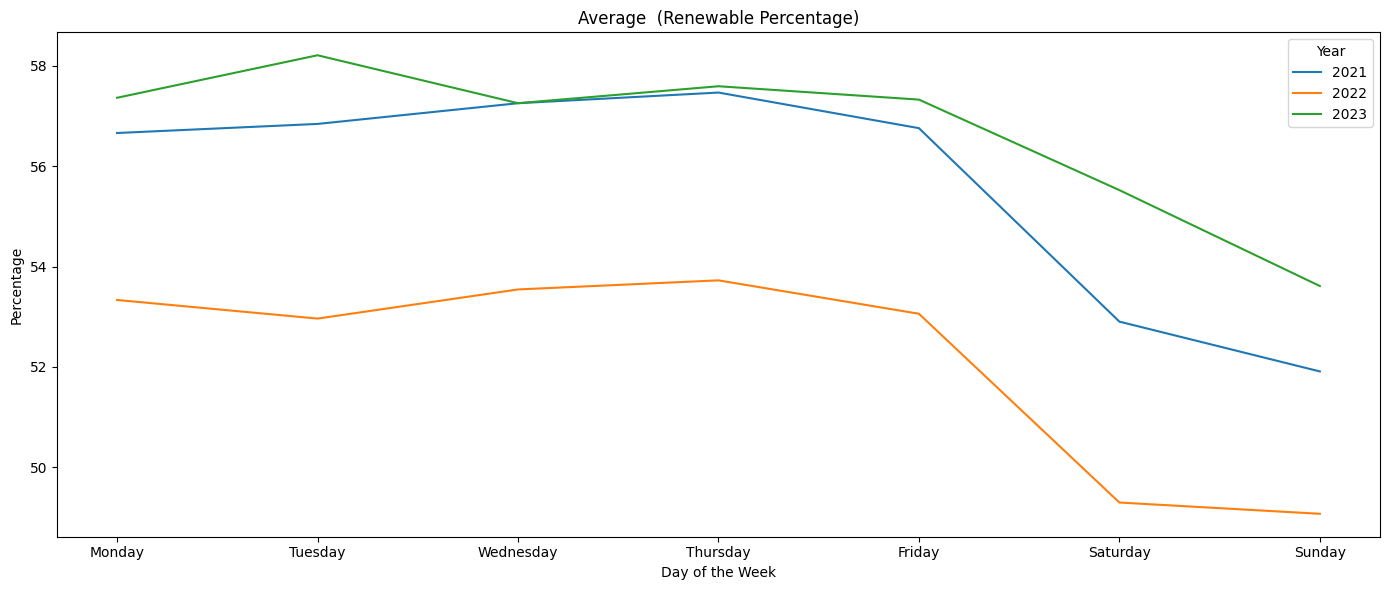

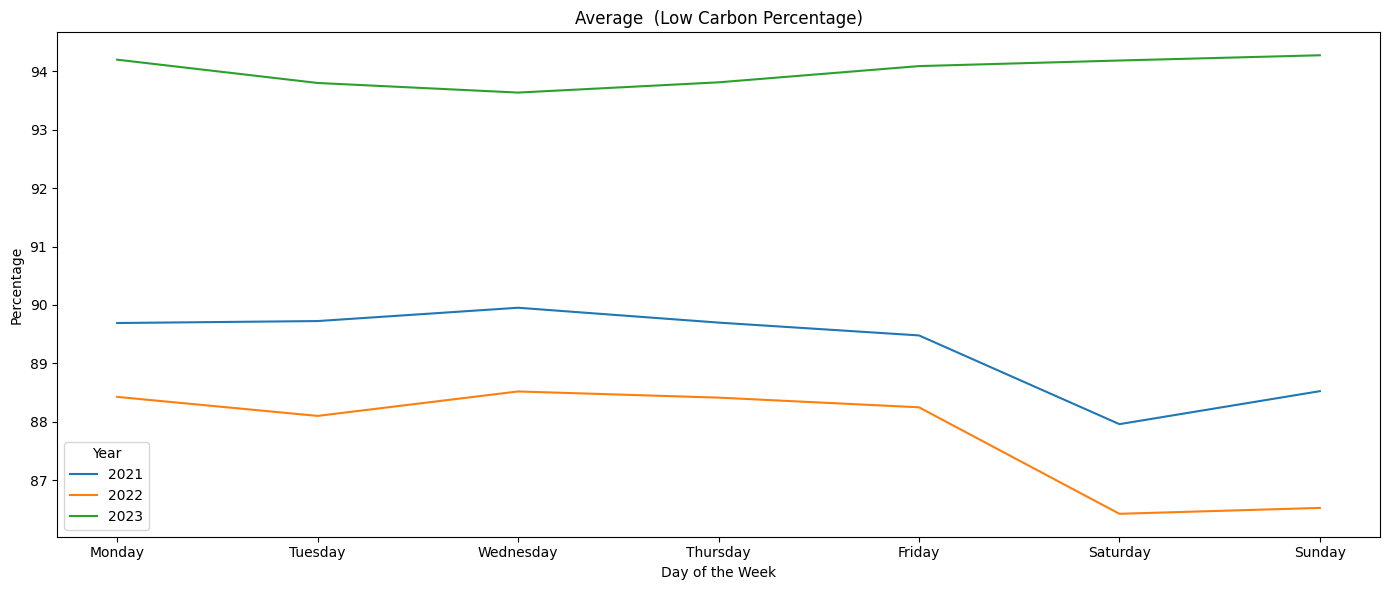

In [37]:
df_visualize.plot_weekday_trends(
    columns=['Renewable Percentage','Low Carbon Percentage'],
    title="Average ",
    ylabel="Percentage"
)


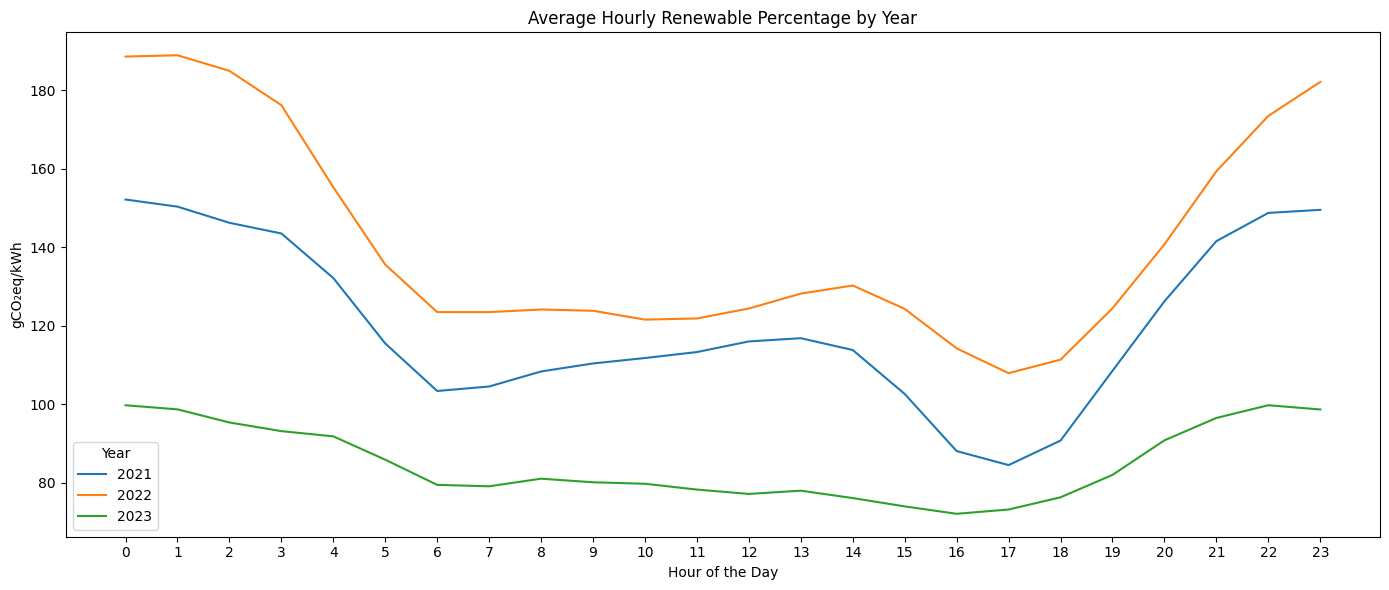

In [38]:
df_visualize.plot_hourly_trends(
    columns=['Carbon Intensity gCO₂eq/kWh (LCA)'],
    title="Average Hourly Renewable Percentage by Year",
    ylabel="gCO₂eq/kWh"
)


Renewable Percentage: 
- Higher on the summer(solar energy or other ..) and lower in winter months

LowCarbon Percentage: 
- is steady

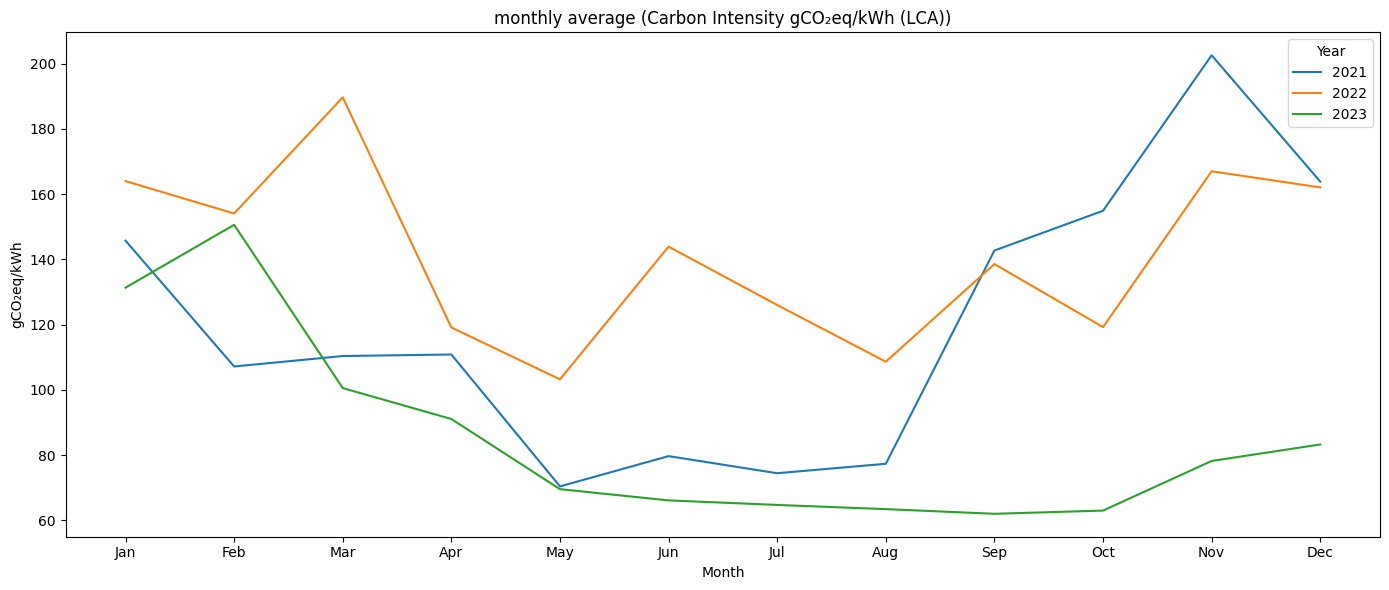

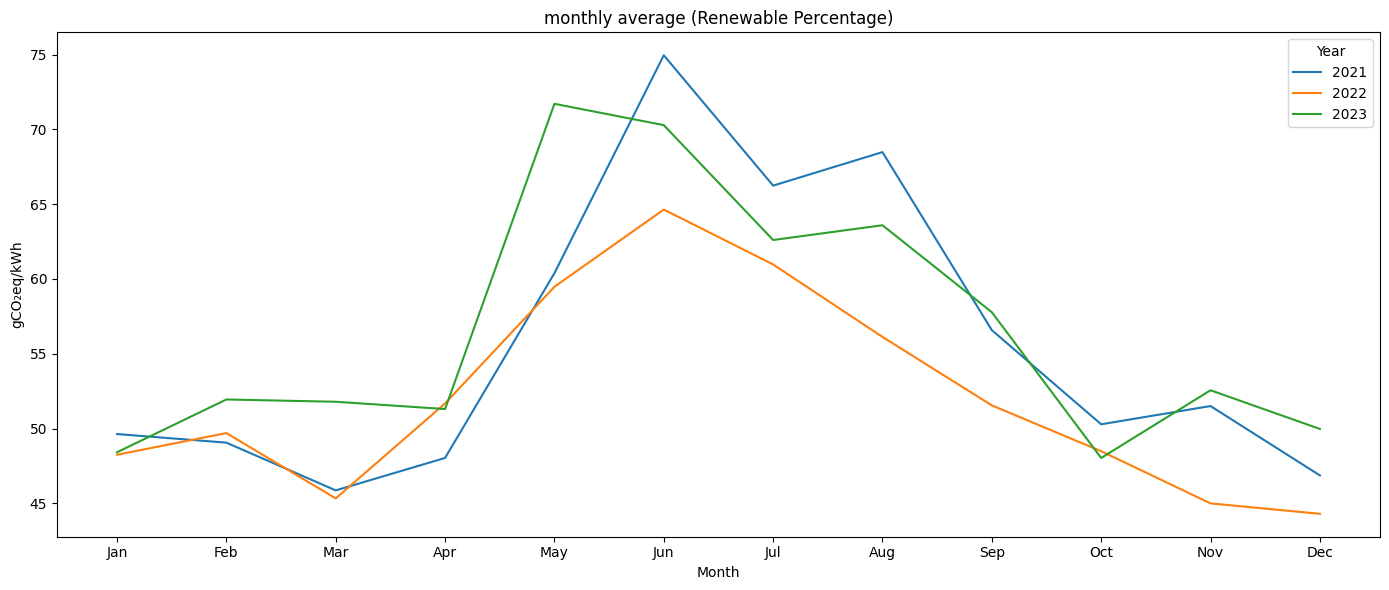

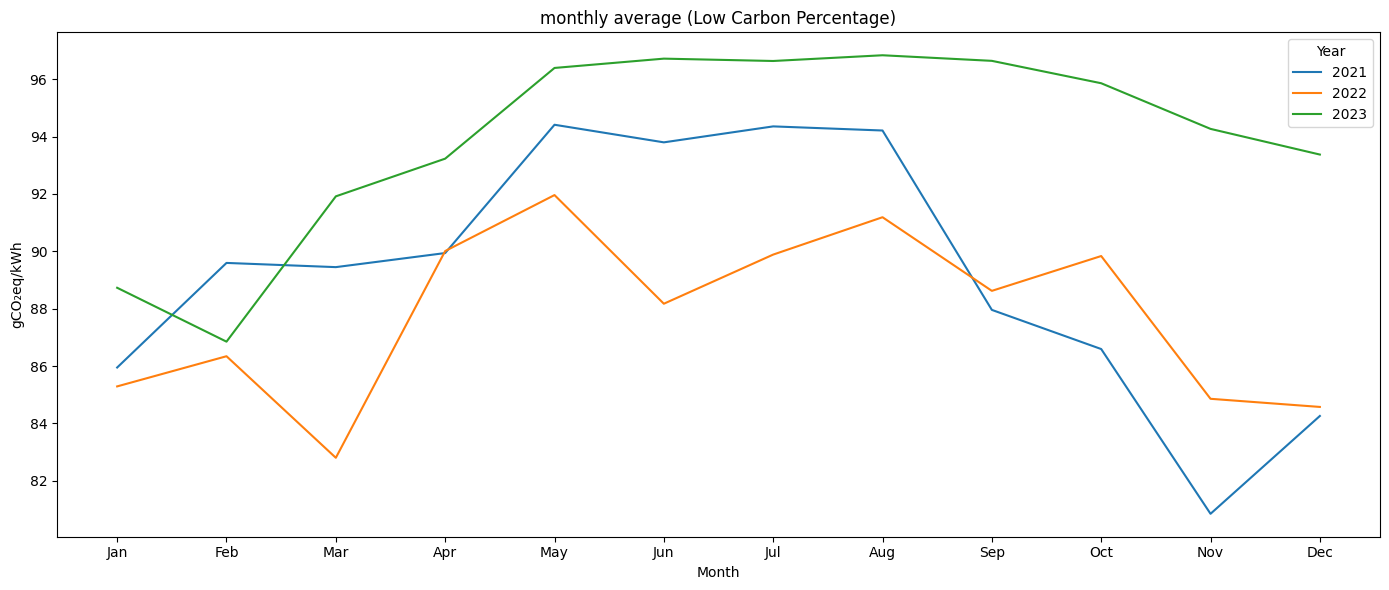

In [39]:
df_visualize.plot_monthly_trends(columns=['Carbon Intensity gCO₂eq/kWh (LCA)',"Renewable Percentage","Low Carbon Percentage"],
                                 title="monthly average",
                                 ylabel="gCO₂eq/kWh")

In [40]:
df_visualize.data.head()

,Carbon Intensity gCO₂eq/kWh (direct),Carbon Intensity gCO₂eq/kWh (LCA),Low Carbon Percentage,Renewable Percentage
Datetime (UTC),,,,
2021-01-01 00:00:00,147.82,187.06,80.25,35.14
2021-01-01 01:00:00,159.56,199.85,78.84,33.17
2021-01-01 02:00:00,140.89,179.60,80.34,33.88
2021-01-01 03:00:00,122.40,159.06,81.49,30.38
2021-01-01 04:00:00,142.60,180.92,80.02,30.54


## Example 2021

august 2021

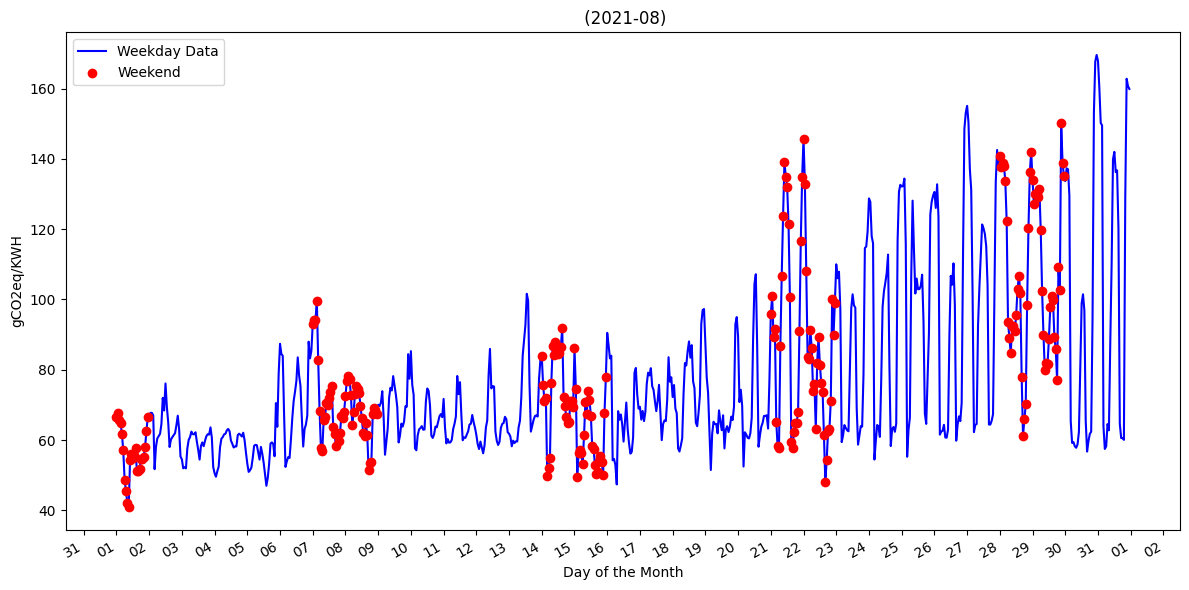

In [41]:
df_visualize.plot_month_with_weekends(
    column='Carbon Intensity gCO₂eq/kWh (LCA)',
    year=2021,
    month=8,
    title="",
    ylabel="gCO2eq/KWH"
)

december

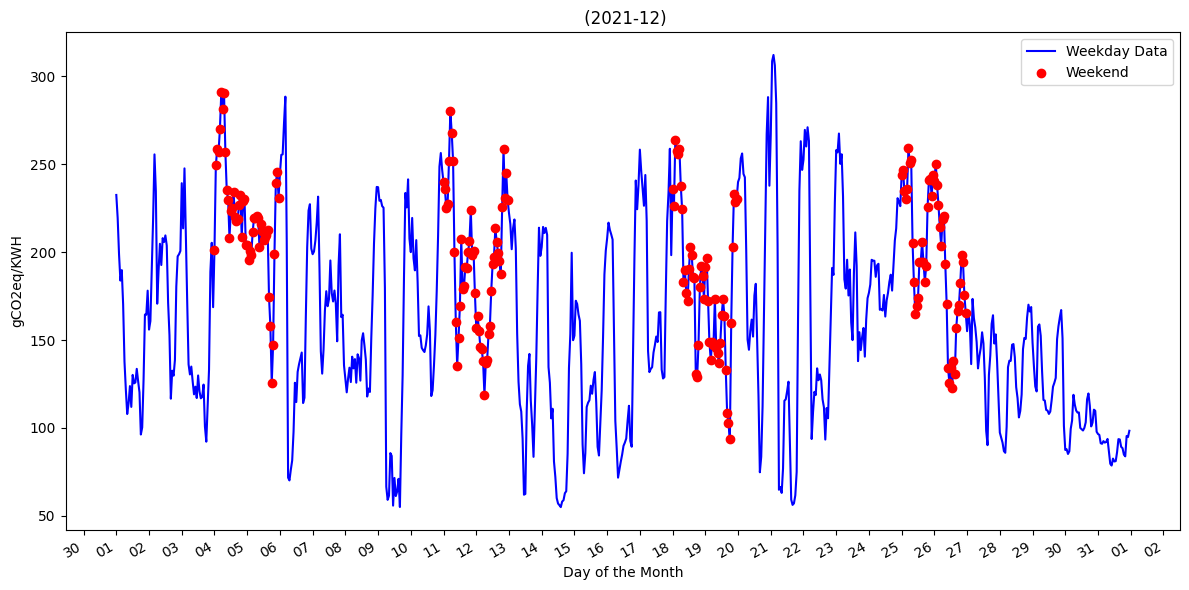

In [42]:
df_visualize.plot_month_with_weekends(
    column='Carbon Intensity gCO₂eq/kWh (LCA)',
    year=2021,
    month=12,
    title="",
    ylabel="gCO2eq/KWH"
)